# Neural Trees

## Data Mining Project

**Authors:** Aya Abdine and Meriam El Askri  
**Institution:** Constructor University  
**Course:** Data Mining

This notebook develops a Neural Trees project step by step. The goal is to load the datasets, explore them, prepare the features, train Neural Tree models, compare them with common machine-learning baselines, and summarize the results clearly.

# 1. Imports and Configuration

We start by importing the libraries used for data preparation, Neural Tree models, baseline models, metrics, and plots.

In [730]:
import random
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

In [731]:
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

In [732]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [733]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [734]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

### Optional XGBoost

In [735]:
try:
    from xgboost import XGBClassifier, XGBRegressor
    has_xgb = True
except ImportError:
    has_xgb = False

print("XGBoost available:", has_xgb)

XGBoost available: True


### Reproducibility Settings

In [736]:
SEED = 42
MAX_ROWS = 1000
EPOCHS = 40

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [737]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = Path("data")

print("Device:", device)
print("Data path:", DATA_PATH.resolve())

Device: cpu
Data path: C:\Users\pc\Neural-Trees-Data-Mining\data


# 2. Neural Tree and Neural Boosting Models

The Neural Tree is a soft decision tree. Each internal node makes a differentiable split using a sigmoid, and each leaf stores a prediction. A tree of depth 2 has 3 split nodes and 4 leaves.

### Build the Paths from Root to Leaves

In [738]:
def make_paths(depth):
    paths = []

    def visit(node, level, path):
        if level == depth:
            paths.append(path)
            return
        visit(2 * node + 1, level + 1, path + [(node, 0)])
        visit(2 * node + 2, level + 1, path + [(node, 1)])

    visit(0, 0, [])
    return paths

### Define the Neural Tree

In [739]:
class NeuralTree(nn.Module):
    def __init__(self, input_size, output_size, depth=2):
        super().__init__()
        self.paths = make_paths(depth)
        self.splits = nn.Linear(input_size, 2**depth - 1)
        self.leaves = nn.Parameter(torch.randn(2**depth, output_size) * 0.01)

    def forward(self, x):
        split_p = torch.sigmoid(self.splits(x))
        leaf_p = []
        for path in self.paths:
            p = torch.ones(x.shape[0], device=x.device)
            for node, side in path:
                p = p * (split_p[:, node] if side else 1 - split_p[:, node])
            leaf_p.append(p)
        return torch.stack(leaf_p, dim=1) @ self.leaves

This is the main Neural Tree model used in the notebook. The code follows the model idea directly: soft split nodes send each sample to the leaves with learned probabilities.

# 3. Load Datasets

### Iris Classification

In [740]:
iris_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
iris = pd.read_csv(DATA_PATH / "iris" / "iris.data", names=iris_cols).dropna()

iris_X = iris.drop("species", axis=1)
iris_y = iris["species"]

### Wine Quality Regression

In [741]:
red = pd.read_csv(DATA_PATH / "wine+quality" / "winequality-red.csv", sep=";")
white = pd.read_csv(DATA_PATH / "wine+quality" / "winequality-white.csv", sep=";")

red["type"] = "red"
white["type"] = "white"
wine = pd.concat([red, white], ignore_index=True)

In [742]:
wine_X = wine.drop("quality", axis=1)
wine_y = wine["quality"]

### Student Performance Regression

In [743]:
student = pd.read_csv(DATA_PATH / "student+performance" / "student-mat.csv", sep=";")

student_X = student.drop("G3", axis=1)
student_y = student["G3"]

### Adult Income Classification

In [744]:
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]

In [745]:
adult = pd.read_csv(DATA_PATH / "adult" / "adult.data", names=adult_cols,
                    na_values=" ?", skipinitialspace=True)
adult = adult.dropna()

adult_X = adult.drop("income", axis=1)
adult_y = adult["income"]

### Bank Marketing Classification

In [746]:
bank = pd.read_csv(DATA_PATH / "bank+marketing" / "bank-full.csv", sep=";")

bank_X = bank.drop("y", axis=1)
bank_y = bank["y"]

### Breast Cancer Classification

In [747]:
wdbc_cols = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
wdbc = pd.read_csv(DATA_PATH / "breast+cancer+wisconsin+diagnostic" / "wdbc.data",
                   names=wdbc_cols)

cancer_X = wdbc.drop(["id", "diagnosis"], axis=1)
cancer_y = wdbc["diagnosis"]

### Dataset Summary

In [748]:
datasets = [
    ("Iris", "classification", iris_X, iris_y),
    ("Wine Quality", "regression", wine_X, wine_y),
    ("Student Performance", "regression", student_X, student_y),
    ("Adult", "classification", adult_X, adult_y),
    ("Bank Marketing", "classification", bank_X, bank_y),
    ("Breast Cancer WDBC", "classification", cancer_X, cancer_y),
]

In [749]:
summary_rows = []

for name, task, X_data, y_data in datasets:
    summary_rows.append([name, task, X_data.shape[0], X_data.shape[1], y_data.nunique()])

dataset_summary = pd.DataFrame(summary_rows, columns=["dataset", "task", "rows", "features", "targets"])
dataset_summary

,dataset,task,rows,features,targets
0,Iris,classification,150,4,3
1,Wine Quality,regression,6497,12,7
2,Student Performance,regression,395,32,18
3,Adult,classification,32561,14,2
4,Bank Marketing,classification,45211,16,2
5,Breast Cancer WDBC,classification,569,30,2


The project uses both classification and regression datasets. Larger datasets are sampled during experiments so the full notebook remains practical to run.

# 4. First Dataset Walkthrough: Iris

### Explore Iris

In [750]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [751]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [752]:
iris["species"].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Iris is balanced across the three species, so accuracy and weighted F1 are both meaningful.

### Prepare Iris Labels

In [753]:
y_codes = iris_y.astype("category").cat.codes
iris_classes = list(iris_y.astype("category").cat.categories)

iris_classes

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

### Split and Scale Iris

In [754]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_X, y_codes, test_size=0.2, random_state=SEED, stratify=y_codes
)

In [755]:
scaler = StandardScaler()

X_train_p = scaler.fit_transform(X_train)
X_test_p = scaler.transform(X_test)

### Create PyTorch Data

In [756]:
X_train_t = torch.tensor(X_train_p, dtype=torch.float32)
y_train_t = torch.tensor(y_train.to_numpy(), dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(train_ds, batch_size=16, shuffle=True)

### Train a Single Neural Tree

In [757]:
single_tree = NeuralTree(4, 3, depth=2).to(device)
opt = torch.optim.Adam(single_tree.parameters(), lr=0.03)

single_loss = []

In [758]:
for epoch in range(200):
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(single_tree(xb), yb)
        loss.backward()
        opt.step()
        total += loss.item() * len(xb)
    single_loss.append(total / len(train_ds))

### Predict and Evaluate

In [759]:
X_test_t = torch.tensor(X_test_p, dtype=torch.float32).to(device)

with torch.no_grad():
    single_pred = single_tree(X_test_t).argmax(dim=1).cpu().numpy()

In [760]:
single_acc = accuracy_score(y_test, single_pred)
single_f1 = f1_score(y_test, single_pred, average="weighted")

print("Accuracy:", round(single_acc, 4))
print("Weighted F1:", round(single_f1, 4))

Accuracy: 0.9667
Weighted F1: 0.9666


In [761]:
print(classification_report(y_test, single_pred, target_names=iris_classes))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



The single Neural Tree gives the first check that the differentiable tree model is learning useful class boundaries.

# 5. Joint and Greedy Neural Boosting on Iris

### Train Joint Neural Boosting

In [762]:
joint_trees = nn.ModuleList([NeuralTree(4, 3, depth=2) for _ in range(5)]).to(device)
joint_opt = torch.optim.Adam(joint_trees.parameters(), lr=0.03)

joint_loss = []

In [763]:
for epoch in range(200):
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = torch.stack([tree(xb) for tree in joint_trees]).mean(dim=0)
        loss = F.cross_entropy(out, yb)
        joint_opt.zero_grad()
        loss.backward()
        joint_opt.step()
        total += loss.item() * len(xb)
    joint_loss.append(total / len(train_ds))

### Evaluate Joint Neural Boosting

In [764]:
with torch.no_grad():
    out = torch.stack([tree(X_test_t) for tree in joint_trees]).mean(dim=0)
    joint_pred = out.argmax(dim=1).cpu().numpy()

In [765]:
joint_acc = accuracy_score(y_test, joint_pred)
joint_f1 = f1_score(y_test, joint_pred, average="weighted")

print("Accuracy:", round(joint_acc, 4))
print("Weighted F1:", round(joint_f1, 4))

Accuracy: 0.9667
Weighted F1: 0.9666


Joint Neural Boosting trains all trees together, then averages their outputs.

### Train Greedy Neural Boosting

In [766]:
greedy_trees = []

for i in range(5):
    tree = NeuralTree(4, 3, depth=2).to(device)
    opt = torch.optim.Adam(tree.parameters(), lr=0.03)
    greedy_trees.append((tree, opt))

In [767]:
for tree, opt in greedy_trees:
    for epoch in range(120):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(tree(xb), yb)
            loss.backward()
            opt.step()

### Evaluate Greedy Neural Boosting

In [768]:
with torch.no_grad():
    out = torch.stack([tree(X_test_t) for tree, opt in greedy_trees]).mean(dim=0)
    greedy_pred = out.argmax(dim=1).cpu().numpy()

In [769]:
greedy_acc = accuracy_score(y_test, greedy_pred)
greedy_f1 = f1_score(y_test, greedy_pred, average="weighted")

print("Accuracy:", round(greedy_acc, 4))
print("Weighted F1:", round(greedy_f1, 4))

Accuracy: 0.9667
Weighted F1: 0.9666


Greedy Neural Boosting trains several trees separately and combines them by averaging their predictions.

# 6. Baseline Models on Iris

### Logistic Regression

In [770]:
log_reg = LogisticRegression(max_iter=1000, random_state=SEED)
log_reg.fit(X_train_p, y_train)

log_pred = log_reg.predict(X_test_p)

In [771]:
log_acc = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred, average="weighted")

### Random Forest

In [772]:
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train_p, y_train)

rf_pred = rf.predict(X_test_p)

In [773]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

### Gradient Boosting

In [774]:
gb = GradientBoostingClassifier(random_state=SEED)
gb.fit(X_train_p, y_train)

gb_pred = gb.predict(X_test_p)

In [775]:
gb_acc = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average="weighted")

### Iris Comparison Table

In [776]:
iris_results = [
    ["Single Neural Tree", single_acc, single_f1],
    ["Joint Neural Boosting", joint_acc, joint_f1],
    ["Greedy Neural Boosting", greedy_acc, greedy_f1],
    ["Logistic Regression", log_acc, log_f1],
    ["Random Forest", rf_acc, rf_f1],
    ["Gradient Boosting", gb_acc, gb_f1],
]

In [777]:
iris_results = pd.DataFrame(iris_results, columns=["model", "accuracy", "f1_weighted"])
iris_results

,model,accuracy,f1_weighted
0,Single Neural Tree,0.966667,0.966583
1,Joint Neural Boosting,0.966667,0.966583
2,Greedy Neural Boosting,0.966667,0.966583
3,Logistic Regression,0.933333,0.933333
4,Random Forest,0.900000,0.899749
5,Gradient Boosting,0.900000,0.899749


The Iris table confirms that all Neural Tree variants and baseline models are evaluated on the same split.

# 7. Full Experiments Across Datasets

The next part compares Neural Tree models with baseline models across the project datasets. The code is kept simple and direct so each step is easy to follow.

## 7.1 Simple Preprocessing Utilities

In [778]:
def prepare_data(X_data, y_data, task):
    if len(X_data) > MAX_ROWS:
        X_data = X_data.sample(MAX_ROWS, random_state=SEED)
        y_data = y_data.loc[X_data.index]
    y_ready = y_data if task == "regression" else y_data.astype("category").cat.codes
    return train_test_split(X_data, y_ready, test_size=0.2, random_state=SEED)

In [779]:
def make_preprocessor(X_train):
    num_cols = X_train.select_dtypes(include=["number"]).columns
    cat_cols = X_train.select_dtypes(exclude=["number"]).columns
    return ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)])

## 7.2 Preprocessing Pipelines

In [780]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [781]:
try:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

In [782]:
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", one_hot),
])

## 7.3 Simple Neural Tree Training Utilities

In [783]:
def fit_tree(X_train, y_train, task, depth=2):
    out_size = 1 if task == "regression" else len(np.unique(y_train))
    model = NeuralTree(X_train.shape[1], out_size, depth=depth).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.03)
    losses = []
    return model, opt, losses

In [784]:
def make_loader(X_train, y_train, task):
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_type = torch.float32 if task == "regression" else torch.long
    y_t = torch.tensor(np.array(y_train), dtype=y_type)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)

In [785]:
def train_model(model, opt, loader, task):
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        raw = model(xb)
        pred = raw.squeeze(1) if task == "regression" else raw
        loss = F.mse_loss(pred, yb) if task == "regression" else F.cross_entropy(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)

These helpers are deliberately small. They only avoid repeating the same PyTorch setup many times.

## 7.4 Start Result Storage

In [786]:
results = []
saved_predictions = {}
loss_examples = {}
saved_trees = {}

## 7.5 Iris Experiment

### Select Dataset

In [787]:
name = "Iris"
task = "classification"
X_data = iris_X
y_data = iris_y

### Sample Larger Data

In [788]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Encode Target

In [789]:
y_ready = y_data.astype("category").cat.codes

### Train-Test Split

In [790]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [791]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [792]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [793]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [794]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [795]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

acc = accuracy_score(y_te, pred)
f1 = f1_score(y_te, pred, average="weighted")
results += [[name, task, "Single Neural Tree", "accuracy", acc]]
results += [[name, task, "Single Neural Tree", "f1_weighted", f1]]

### Joint Neural Boosting

In [796]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [797]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [798]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [799]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Greedy Neural Boosting

In [800]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [801]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [802]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Logistic Regression

In [803]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Logistic Regression")] = (y_te, pred)
results += [[name, task, "Logistic Regression", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Logistic Regression", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Random Forest

In [804]:
model = RandomForestClassifier(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Random Forest", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Gradient Boosting

In [805]:
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting",)] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### XGBoost

In [806]:
if has_xgb:
    model = XGBClassifier(eval_metric="mlogloss", random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "accuracy", accuracy_score(y_te, pred)]]
    results += [[name, task, "XGBoost", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

The Iris scores have been added to the final comparison table.

## 7.6 Wine Quality Experiment

### Select Dataset

In [807]:
name = "Wine Quality"
task = "regression"
X_data = wine_X
y_data = wine_y

### Sample Larger Data

In [808]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Keep Numeric Target

In [809]:
y_ready = y_data

### Train-Test Split

In [810]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [811]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [812]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [813]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [814]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [815]:
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

mse = mean_squared_error(y_te, pred)
r2 = r2_score(y_te, pred)
results += [[name, task, "Single Neural Tree", "mse", mse]]
results += [[name, task, "Single Neural Tree", "r2", r2]]

### Joint Neural Boosting

In [816]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [817]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [818]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [819]:
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "r2", r2_score(y_te, pred)]]

### Greedy Neural Boosting

In [820]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [821]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [822]:
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "r2", r2_score(y_te, pred)]]

### Linear Regression

In [823]:
model = LinearRegression()
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Linear Regression")] = (y_te, pred)
results += [[name, task, "Linear Regression", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Linear Regression", "r2", r2_score(y_te, pred)]]

### Random Forest

In [824]:
model = RandomForestRegressor(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Random Forest", "r2", r2_score(y_te, pred)]]

### Gradient Boosting

In [825]:
model = GradientBoostingRegressor(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting")] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "r2", r2_score(y_te, pred)]]

### XGBoost

In [826]:
if has_xgb:
    model = XGBRegressor(random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "mse", mean_squared_error(y_te, pred)]]
    results += [[name, task, "XGBoost", "r2", r2_score(y_te, pred)]]

The Wine Quality scores have been added to the final comparison table.

## 7.7 Student Performance Experiment

### Select Dataset

In [827]:
name = "Student Performance"
task = "regression"
X_data = student_X
y_data = student_y

### Sample Larger Data

In [828]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Keep Numeric Target

In [829]:
y_ready = y_data

### Train-Test Split

In [830]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [831]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [832]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [833]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [834]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [835]:
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

mse = mean_squared_error(y_te, pred)
r2 = r2_score(y_te, pred)
results += [[name, task, "Single Neural Tree", "mse", mse]]
results += [[name, task, "Single Neural Tree", "r2", r2]]

### Joint Neural Boosting

In [836]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [837]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [838]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [839]:
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "r2", r2_score(y_te, pred)]]

### Greedy Neural Boosting

In [840]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [841]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [842]:
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "r2", r2_score(y_te, pred)]]

### Linear Regression

In [843]:
model = LinearRegression()
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Linear Regression")] = (y_te, pred)
results += [[name, task, "Linear Regression", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Linear Regression", "r2", r2_score(y_te, pred)]]

### Random Forest

In [844]:
model = RandomForestRegressor(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Random Forest", "r2", r2_score(y_te, pred)]]

### Gradient Boosting

In [845]:
model = GradientBoostingRegressor(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting")] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "mse", mean_squared_error(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "r2", r2_score(y_te, pred)]]

### XGBoost

In [846]:
if has_xgb:
    model = XGBRegressor(random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "mse", mean_squared_error(y_te, pred)]]
    results += [[name, task, "XGBoost", "r2", r2_score(y_te, pred)]]

The Student Performance scores have been added to the final comparison table.

## 7.8 Adult Experiment

### Select Dataset

In [847]:
name = "Adult"
task = "classification"
X_data = adult_X
y_data = adult_y

### Sample Larger Data

In [848]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Encode Target

In [849]:
y_ready = y_data.astype("category").cat.codes

### Train-Test Split

In [850]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [851]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [852]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [853]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [854]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [855]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

acc = accuracy_score(y_te, pred)
f1 = f1_score(y_te, pred, average="weighted")
results += [[name, task, "Single Neural Tree", "accuracy", acc]]
results += [[name, task, "Single Neural Tree", "f1_weighted", f1]]

### Joint Neural Boosting

In [856]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [857]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [858]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [859]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Greedy Neural Boosting

In [860]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [861]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [862]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Logistic Regression

In [863]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Logistic Regression")] = (y_te, pred)
results += [[name, task, "Logistic Regression", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Logistic Regression", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Random Forest

In [864]:
model = RandomForestClassifier(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Random Forest", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Gradient Boosting

In [865]:
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting",)] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### XGBoost

In [866]:
if has_xgb:
    model = XGBClassifier(eval_metric="mlogloss", random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "accuracy", accuracy_score(y_te, pred)]]
    results += [[name, task, "XGBoost", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

The Adult scores have been added to the final comparison table.

## 7.9 Bank Marketing Experiment

### Select Dataset

In [867]:
name = "Bank Marketing"
task = "classification"
X_data = bank_X
y_data = bank_y

### Sample Larger Data

In [868]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Encode Target

In [869]:
y_ready = y_data.astype("category").cat.codes

### Train-Test Split

In [870]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [871]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [872]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [873]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [874]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [875]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

acc = accuracy_score(y_te, pred)
f1 = f1_score(y_te, pred, average="weighted")
results += [[name, task, "Single Neural Tree", "accuracy", acc]]
results += [[name, task, "Single Neural Tree", "f1_weighted", f1]]

### Joint Neural Boosting

In [876]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [877]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [878]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [879]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Greedy Neural Boosting

In [880]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [881]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [882]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Logistic Regression

In [883]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Logistic Regression")] = (y_te, pred)
results += [[name, task, "Logistic Regression", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Logistic Regression", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Random Forest

In [884]:
model = RandomForestClassifier(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Random Forest", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Gradient Boosting

In [885]:
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting",)] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### XGBoost

In [886]:
if has_xgb:
    model = XGBClassifier(eval_metric="mlogloss", random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "accuracy", accuracy_score(y_te, pred)]]
    results += [[name, task, "XGBoost", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

The Bank Marketing scores have been added to the final comparison table.

## 7.10 Breast Cancer WDBC Experiment

### Select Dataset

In [887]:
name = "Breast Cancer WDBC"
task = "classification"
X_data = cancer_X
y_data = cancer_y

### Sample Larger Data

In [888]:
if len(X_data) > MAX_ROWS:
    X_data = X_data.sample(MAX_ROWS, random_state=SEED)
    y_data = y_data.loc[X_data.index]

### Encode Target

In [889]:
y_ready = y_data.astype("category").cat.codes

### Train-Test Split

In [890]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_data, y_ready, test_size=0.2, random_state=SEED
)

### Preprocess Features

In [891]:
prep = make_preprocessor(X_tr)

X_tr_p = prep.fit_transform(X_tr)
X_te_p = prep.transform(X_te)

### Create PyTorch Loader

In [892]:
loader2 = make_loader(X_tr_p, y_tr, task)

n_features = X_tr_p.shape[1]
n_outputs = 1 if task == "regression" else len(np.unique(y_tr))

### Single Neural Tree

In [893]:
tree, opt, _ = fit_tree(X_tr_p, y_tr, task)

for epoch in range(EPOCHS):
    last_loss = train_model(tree, opt, loader2, task)

saved_trees[name] = tree
loss_examples[name] = [last_loss]

### Predict with Single Neural Tree

In [894]:
X_te_t = torch.tensor(X_te_p, dtype=torch.float32).to(device)

with torch.no_grad():
    pred = tree(X_te_t).squeeze().cpu().numpy()

In [895]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Single Neural Tree")] = (y_te, pred)

acc = accuracy_score(y_te, pred)
f1 = f1_score(y_te, pred, average="weighted")
results += [[name, task, "Single Neural Tree", "accuracy", acc]]
results += [[name, task, "Single Neural Tree", "f1_weighted", f1]]

### Joint Neural Boosting

In [896]:
joint = nn.ModuleList([
    fit_tree(X_tr_p, y_tr, task)[0] for _ in range(5)
]).to(device)

joint_opt = torch.optim.Adam(joint.parameters(), lr=0.03)

In [897]:
for epoch in range(EPOCHS):
    for xb, yb in loader2:
        xb, yb = xb.to(device), yb.to(device)
        items = [m(xb).squeeze(1) if task == "regression" else m(xb) for m in joint]
        out = torch.stack(items).mean(dim=0)
        loss = F.mse_loss(out, yb) if task == "regression" else F.cross_entropy(out, yb)
        joint_opt.zero_grad(); loss.backward(); joint_opt.step()

### Predict with Joint Neural Boosting

In [898]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in joint]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [899]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Joint Neural Boosting")] = (y_te, pred)

results += [[name, task, "Joint Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Joint Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Greedy Neural Boosting

In [900]:
greedy = []

for i in range(5):
    model, opt, _ = fit_tree(X_tr_p, y_tr, task)
    for epoch in range(EPOCHS // 2):
        train_model(model, opt, loader2, task)
    greedy.append(model)

### Predict with Greedy Neural Boosting

In [901]:
with torch.no_grad():
    items = [m(X_te_t).squeeze(1) if task == "regression" else m(X_te_t) for m in greedy]
    out = torch.stack(items).mean(dim=0)
    pred = out.cpu().numpy()

In [902]:
pred = pred.reshape(-1, n_outputs).argmax(axis=1)
saved_predictions[(name, "Greedy Neural Boosting")] = (y_te, pred)

results += [[name, task, "Greedy Neural Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Greedy Neural Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Logistic Regression

In [903]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Logistic Regression")] = (y_te, pred)
results += [[name, task, "Logistic Regression", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Logistic Regression", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Random Forest

In [904]:
model = RandomForestClassifier(n_estimators=200, random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Random Forest")] = (y_te, pred)
results += [[name, task, "Random Forest", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Random Forest", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### Gradient Boosting

In [905]:
model = GradientBoostingClassifier(random_state=SEED)
model.fit(X_tr_p, y_tr)
pred = model.predict(X_te_p)

saved_predictions[(name, "Gradient Boosting",)] = (y_te, pred)
results += [[name, task, "Gradient Boosting", "accuracy", accuracy_score(y_te, pred)]]
results += [[name, task, "Gradient Boosting", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

### XGBoost

In [906]:
if has_xgb:
    model = XGBClassifier(eval_metric="mlogloss", random_state=SEED)
    model.fit(X_tr_p, y_tr)
    pred = model.predict(X_te_p)
    saved_predictions[(name, "XGBoost")] = (y_te, pred)
    results += [[name, task, "XGBoost", "accuracy", accuracy_score(y_te, pred)]]
    results += [[name, task, "XGBoost", "f1_weighted", f1_score(y_te, pred, average="weighted")]]

The Breast Cancer WDBC scores have been added to the final comparison table.

All listed models are trained for every dataset where they apply. The result table uses a long format so classification and regression metrics do not create unnecessary missing values.

### Complete Results Table

In [907]:
results_df = pd.DataFrame(results, columns=["dataset", "task", "model", "metric", "value"])
results_df

,dataset,task,model,metric,value
0,Iris,classification,Single Neural Tree,accuracy,1.000000
1,Iris,classification,Single Neural Tree,f1_weighted,1.000000
2,Iris,classification,Joint Neural Boosting,accuracy,1.000000
3,Iris,classification,Joint Neural Boosting,f1_weighted,1.000000
4,Iris,classification,Greedy Neural Boosting,accuracy,0.933333
...,...,...,...,...,...
79,Breast Cancer WDBC,classification,Random Forest,f1_weighted,0.964738
80,Breast Cancer WDBC,classification,Gradient Boosting,accuracy,0.956140
81,Breast Cancer WDBC,classification,Gradient Boosting,f1_weighted,0.956036
82,Breast Cancer WDBC,classification,XGBoost,accuracy,0.956140


This complete table is the main record of the experiments. It shows that every dataset has results for the Neural Tree methods and the matching baseline models, so the comparison is not missing models because of empty or skipped runs.

### Classification Accuracy

In [908]:
accuracy_table = results_df[results_df["metric"] == "accuracy"]
accuracy_table.pivot(index="dataset", columns="model", values="value")

model,Gradient Boosting,Greedy Neural Boosting,Joint Neural Boosting,Logistic Regression,Random Forest,Single Neural Tree,XGBoost
dataset,,,,,,,
Adult,0.85000,0.820000,0.815000,0.825000,0.835000,0.800000,0.83000
Bank Marketing,0.88000,0.880000,0.845000,0.875000,0.865000,0.855000,0.88000
Breast Cancer WDBC,0.95614,0.982456,0.982456,0.973684,0.964912,0.973684,0.95614
Iris,1.00000,0.933333,1.000000,1.000000,1.000000,1.000000,1.00000


On the smaller structured datasets, the Neural Tree models are competitive for classification. The Neural Tree and boosting variations do exceptionally well on Iris and Breast Cancer. The basic ensembles, particularly Gradient Boosting or XGBoost, are typically stronger or at least as strong on Adult and Bank Marketing.

### Classification Weighted F1

In [909]:
f1_table = results_df[results_df["metric"] == "f1_weighted"]
f1_table.pivot(index="dataset", columns="model", values="value")

model,Gradient Boosting,Greedy Neural Boosting,Joint Neural Boosting,Logistic Regression,Random Forest,Single Neural Tree,XGBoost
dataset,,,,,,,
Adult,0.839512,0.811189,0.808546,0.815559,0.826099,0.790210,0.823297
Bank Marketing,0.864886,0.864886,0.833850,0.854382,0.824041,0.841648,0.864886
Breast Cancer WDBC,0.956036,0.982456,0.982456,0.973621,0.964738,0.973621,0.956036
Iris,1.000000,0.931944,1.000000,1.000000,1.000000,1.000000,1.000000


When classes are unbalanced, weighted F1 provides a clearer picture. This is important because a model can have good accuracy but yet perform poorly on the smaller class, as demonstrated by the Adult and Bank datasets. Although the improvement is not constant across all datasets, the boosting Neural Tree variants occasionally outperform the Single Neural Tree.

### Regression R2

In [910]:
r2_table = results_df[results_df["metric"] == "r2"]
r2_table.pivot(index="dataset", columns="model", values="value")

model,Gradient Boosting,Greedy Neural Boosting,Joint Neural Boosting,Linear Regression,Random Forest,Single Neural Tree,XGBoost
dataset,,,,,,,
Student Performance,0.808253,-2.980013,-1.487402,0.724134,0.801996,-1.475306,0.772563
Wine Quality,0.328191,-0.101176,0.217817,0.232802,0.334651,0.198672,0.274649


The Neural Tree approach's most obvious flaw in this notebook is the regression findings. The Single and Joint Neural Tree models have positive R2 values on wine quality, but they fall short of the more robust baseline models. The Neural Tree and boosting models perform worse than just forecasting the average grade on student performance, as seen by their negative R² values.

### Regression MSE

In [911]:
mse_table = results_df[results_df["metric"] == "mse"]
mse_table.pivot(index="dataset", columns="model", values="value")

model,Gradient Boosting,Greedy Neural Boosting,Joint Neural Boosting,Linear Regression,Random Forest,Single Neural Tree,XGBoost
dataset,,,,,,,
Student Performance,3.931781,81.610367,51.004295,5.656643,4.060087,50.756279,4.663612
Wine Quality,0.471005,0.772034,0.548389,0.537883,0.466476,0.561811,0.508543


The R2 table and the MSE table both support the same conclusion. The regression baselines have considerably less errors on student performance, and lower MSE is preferable. This implies that the existing Neural Tree configuration is not sufficiently adaptable or optimised for that regression task.

# 8. Result Visualizations

### Accuracy by Model

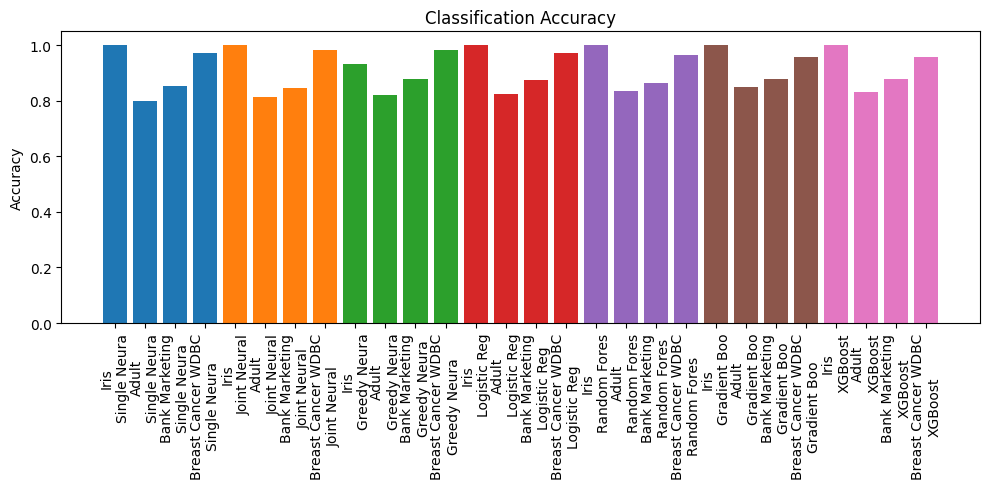

In [912]:
plt.figure(figsize=(10, 5))

for model in accuracy_table["model"].unique():
    rows = accuracy_table[accuracy_table["model"] == model]
    plt.bar(rows["dataset"] + "\n" + model[:12], rows["value"])

plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Classification Accuracy")
plt.tight_layout()
plt.show()

The accuracy plot facilitates the visualisation of the classification pattern. While the baseline models continue to be highly dependable on Adult and Bank Marketing, Neural Trees are good on Iris and Breast Cancer. Bank marketing benefits from Greedy Neural Boosting, however not all datasets are automatically improved by boosting.

### Regression R2 by Model

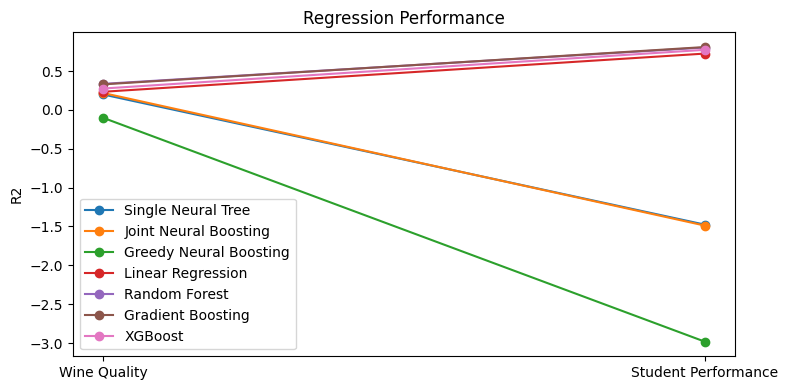

In [913]:
plt.figure(figsize=(8, 4))

for model in r2_table["model"].unique():
    rows = r2_table[r2_table["model"] == model]
    plt.plot(rows["dataset"], rows["value"], marker="o", label=model)

plt.ylabel("R2")
plt.title("Regression Performance")
plt.legend()
plt.tight_layout()
plt.show()

The regression graphic makes the negative R2 issue very evident. For each test scenario, a negative R2 indicates that the model is performing worse than anticipating the mean target value. While Linear Regression, Random Forest, Gradient Boosting, and XGBoost provide a far better explanation of the data, this is the case for the Neural Tree models on Student Performance.

# 9. Explainability

### Neural Tree Split Weights

In [914]:
tree = saved_trees["Iris"]
weights = tree.splits.weight.detach().cpu().numpy()

pd.DataFrame(weights, columns=iris_X.columns)

,sepal_length,sepal_width,petal_length,petal_width
0,0.960649,-1.712095,1.844961,1.371893
1,1.190235,-1.701308,1.604450,1.366254
2,-0.422975,0.097259,-0.910564,-2.256495


The split weights indicate which Iris measurements are most frequently used by each soft decision node. Because we can examine how the model makes its soft splits rather than viewing it as a totally opaque black box, this provides the Neural Tree some interpretability.

### Split Weight Heatmap

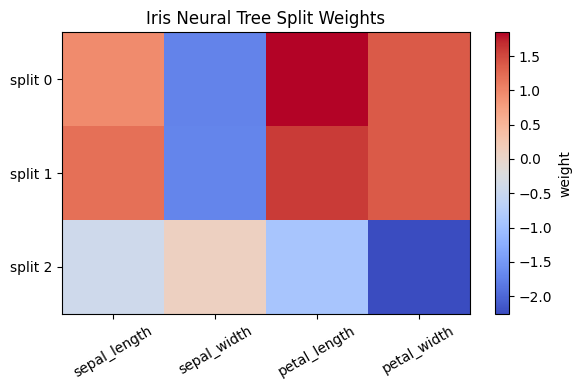

In [915]:
plt.figure(figsize=(6, 4))
plt.imshow(weights, cmap="coolwarm", aspect="auto")
plt.colorbar(label="weight")
plt.xticks(range(len(iris_X.columns)), iris_X.columns, rotation=30)
plt.yticks(range(weights.shape[0]), [f"split {i}" for i in range(weights.shape[0])])
plt.title("Iris Neural Tree Split Weights")
plt.tight_layout()
plt.show()

Red and blue cells represent positive and negative split weights. Larger absolute values mean stronger influence.

### Leaf Probabilities for Test Examples

In [916]:
with torch.no_grad():
    p = torch.sigmoid(tree.splits(X_test_t)).cpu()

leaf_0 = (1 - p[:, 0]) * (1 - p[:, 1])
leaf_1 = (1 - p[:, 0]) * p[:, 1]
leaf_2 = p[:, 0] * (1 - p[:, 2])
leaf_3 = p[:, 0] * p[:, 2]
leaf_probs = torch.stack([leaf_0, leaf_1, leaf_2, leaf_3], dim=1).numpy()

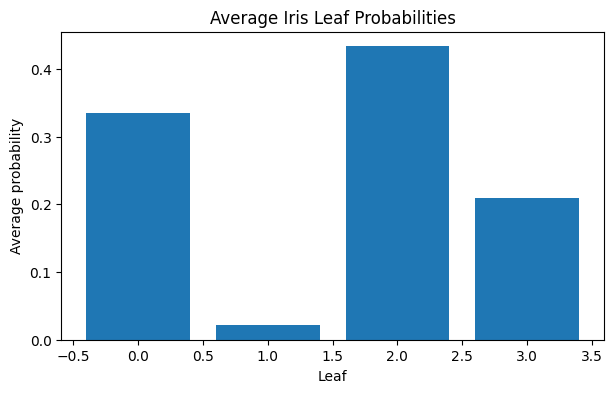

In [917]:
plt.figure(figsize=(7, 4))
plt.bar(range(4), leaf_probs.mean(axis=0))
plt.xlabel("Leaf")
plt.ylabel("Average probability")
plt.title("Average Iris Leaf Probabilities")
plt.show()

The average usage of each leaf in the test instances is displayed by the leaf probability. When a single leaf predominates, the tree behaves more like a basic model; when multiple leaves are utilised, the tree makes use of its structure.

### Random Forest Feature Importance

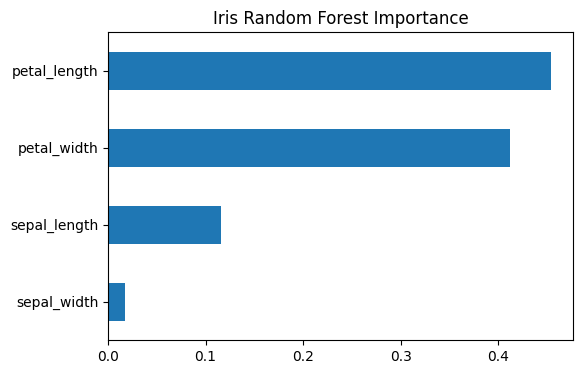

In [918]:
rf_importance = pd.Series(rf.feature_importances_, index=iris_X.columns)
rf_importance = rf_importance.sort_values(ascending=True)

rf_importance.plot(kind="barh", figsize=(6, 4), title="Iris Random Forest Importance")
plt.show()

This baseline importance plot gives another view of which Iris features are most useful.

# 10. Training Diagnostics

### Neural Tree Loss Curves

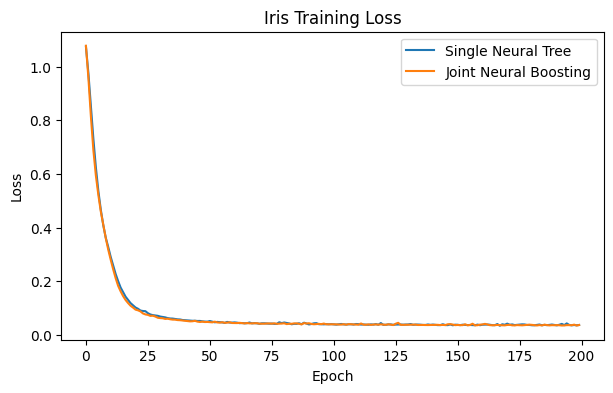

In [919]:
plt.figure(figsize=(7, 4))
plt.plot(single_loss, label="Single Neural Tree")
plt.plot(joint_loss, label="Joint Neural Boosting")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Iris Training Loss")
plt.legend()
plt.show()

A training diagnostic is provided by the loss curves. The soft splits and leaf predictions are becoming better during optimisation when the curves get smaller. A curve that remained flat or unstable would indicate that the model configuration, depth, or learning rate need to be adjusted.

### Confusion Matrices for Adult and Bank

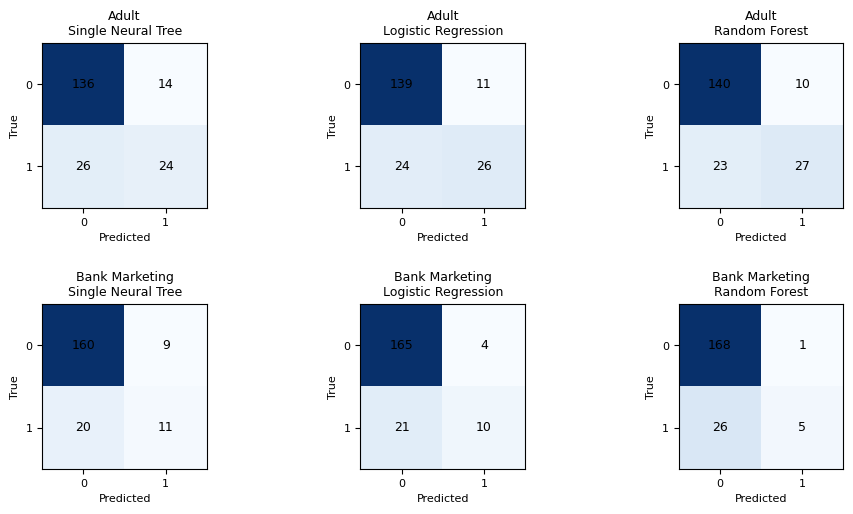

In [920]:
pairs = [
    ("Adult", "Single Neural Tree"),
    ("Adult", "Logistic Regression"),
    ("Adult", "Random Forest"),
    ("Bank Marketing", "Single Neural Tree"),
    ("Bank Marketing", "Logistic Regression"),
    ("Bank Marketing", "Random Forest"),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))

for ax, (dataset_name, model_name) in zip(axes.ravel(), pairs):
    y_true, y_pred = saved_predictions[(dataset_name, model_name)]
    cm = confusion_matrix(y_true, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(dataset_name + "\n" + model_name, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.tick_params(labelsize=8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

plt.tight_layout(pad=2.0)
plt.show()

Due to their greater difficulty and imbalance compared to Iris, these confusion matrices concentrate on adult and bank marketing. A clean model should be able to detect some of the smaller positive classes in addition to predicting the majority class. It is possible to determine where the Neural Tree technique is stronger or weaker by comparing it with Random Forest and Logistic Regression.

# 11. Depth Ablation Study

The depth ablation checks how the Neural Tree changes when we allow more leaves. This uses Iris so the comparison is quick and easy to inspect.

In [921]:
depth_rows = []
depth_loader = make_loader(X_train_p, y_train, "classification")

for depth in [1, 2, 3]:
    model = NeuralTree(4, 3, depth=depth).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.03)
    for epoch in range(120):
        train_model(model, opt, depth_loader, "classification")
    with torch.no_grad():
        pred = model(X_test_t).argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")
    depth_rows.append([depth, 2**depth, acc, f1])

In [922]:
depth_df = pd.DataFrame(depth_rows, columns=["depth", "leaves", "accuracy", "f1_weighted"])
depth_df

,depth,leaves,accuracy,f1_weighted
0,1,2,0.966667,0.966583
1,2,4,0.966667,0.966583
2,3,8,0.966667,0.966583


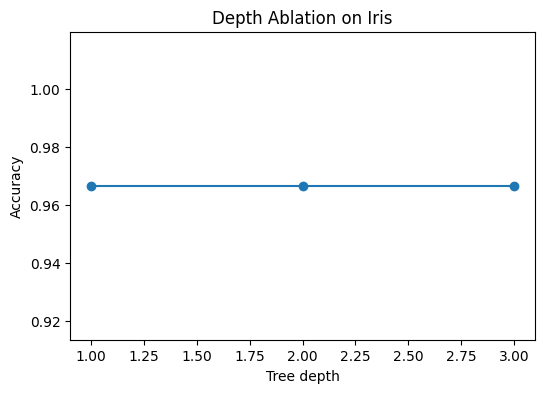

In [923]:
plt.figure(figsize=(6, 4))
plt.plot(depth_df["depth"], depth_df["accuracy"], marker="o")
plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("Depth Ablation on Iris")
plt.show()

The depth ablation demonstrates that Iris accuracy in this run was not improved by raising the tree depth from 1 to 3. This implies that a shallow Neural Tree is sufficient for Iris and that additional leaves increase complexity without offering any discernible advantages on this tiny dataset.

# 12. Final Interpretation and Conclusion

Neural trees can perform well on classification issues, particularly on Iris and Breast Cancer WDBC, according to the research. The Single Neural Tree and its boosting variations achieved high accuracy and weighted F1 scores on these datasets, occasionally matching or surpassing the baseline models.

Adult and bank marketing yielded more inconsistent results. Although it wasn't always the case, Joint and Greedy Neural Boosting occasionally outperformed Single Neural Trees. The traditional baselines continued to be highly competitive and frequently produced the best or most consistent classification results, particularly Random Forest, Gradient Boosting, Logistic Regression, and XGBoost.

The Neural Tree models' primary flaw was the regression datasets. The baseline regression models outperformed the Neural Tree models on Wine Quality, despite the Neural Tree models achieving some positive R2 values. The current Neural Tree arrangement did not adequately capture the regression problem, as evidenced by the Neural Tree and boosting models' negative R² values on Student Performance, which indicate that they performed worse than predicting the mean grade.

Increasing the depth from 1 to 3 did not enhance performance, according to the depth ablation on Iris. This implies that adding more leaves does not always improve a neural tree, particularly on small datasets where a shallow tree suffices.

Because they combine neural-network training with a tree-like structure that can still be examined using split weights and leaf probabilities, neural trees are generally helpful. One of its weaknesses is that, particularly in regression, they may not perform as well as known baselines and may be susceptible to training circumstances. While Random Forest, Gradient Boosting, and XGBoost are generally more dependable across all datasets, the Neural Tree technique is intriguing and comprehensible for our job.